# 13 · ShakerMaker vs SW4

Cross-validate the FK engine against a full **SW4** finite-difference run on the *same* model: a 4-layer crust, 100 FFSP point sources, and 2 surface stations. Both solvers are driven from one ShakerMaker export (`data/model_summary.h5`), so source and geometry are identical — any difference is method, not setup.

Run from this `notebooks/` folder (paths point to `../data`). Needs `obspy` for the band-pass filter.

In [1]:
import ast
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt

from shakermaker import shakermaker
from shakermaker.crustmodel import CrustModel
from shakermaker.pointsource import PointSource
from shakermaker.faultsource import FaultSource
from shakermaker.station import Station
from shakermaker.stationlist import StationList
from shakermaker.stf_extensions import Discrete

DATA = Path('../data')
PACKAGE_H5 = DATA / 'model_summary.h5'
FMIN, FMAX = 0.25, 15.0   # comparison band (Hz)


    ▄████████     ▄█    █▄     ▄████████     ▄█   ▄█▄    ▄████████    ▄████████
    ███    ███   ███    ███    ███    ███    ███ ▄███▀   ███    ███   ███    ███
    ███    █▀    ███    ███    ███    ███    ███▐██▀     ███    █▀    ███    ███
    ███         ▄███▄▄▄▄███▄▄  ███    ███   ▄█████▀     ▄███▄▄▄      ▄███▄▄▄▄██▀
  ▀███████████  ▀███▀▀▀▀███▀  ▀███████████  ▀█████▄    ▀▀███▀▀▀     ▀▀███▀▀▀▀▀
           ███   ███    ███    ███    ███    ███▐██▄     ███    █▄   ▀███████████
     ▄█    ███   ███    ███    ███    ███    ███ ▀███▄   ███    ███   ███    ███
   ▄████████▀    ███    █▀     ███    █▀     ███   ▀█▀   ██████████   ███    ███
                                                                      ███    ███

         ▄▄▄▄███▄▄▄▄      ▄████████    ▄█   ▄█▄    ▄████████    ▄████████
       ▄██▀▀▀███▀▀▀██▄   ███    ███    ███ ▄███▀   ███    ███   ███    ███
       ███   ███   ███   ███    ███    ███▐██▀     ███    █▀    ███    ███
       ███   ███   ███   ███    ███   ▄█████▀  

## Step 1 — Rebuild the model from the SW4 package

### The crust

Crust Model with 4 layers.
 Layer  | Depth  | Thick  | Vp     | Vs     | rho    | Qa     | Qb
       1|    0.00|    0.20|    1.32|    0.75|    2.40|  1000.0|  1000.0
       2|    0.20|    0.80|    2.75|    1.57|    2.50|  1000.0|  1000.0
       3|    1.00|   14.50|    5.50|    3.14|    2.50|  1000.0|  1000.0
       4|   15.50|    0.00|    7.00|    4.00|    2.67|  1000.0|  1000.0



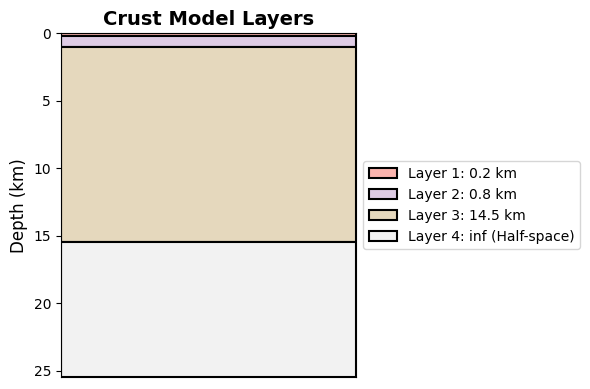

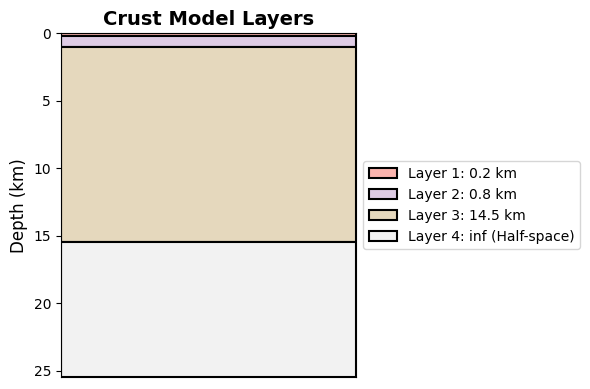

In [2]:
with h5py.File(PACKAGE_H5, 'r') as f:
    g = f['crust']
    thickness, vp, vs = g['thickness_km'][:], g['vp_km_s'][:], g['vs_km_s'][:]
    rho, qp, qs = g['rho_g_cm3'][:], g['qp'][:], g['qs'][:]

crust = CrustModel(len(thickness))
for i in range(len(thickness)):
    crust.add_layer(thickness[i], vp[i], vs[i], rho[i], qp[i], qs[i])
print(crust)
crust.plot()

### The 100 sources (Discrete slip-rate STFs)

In [3]:
with h5py.File(PACKAGE_H5, 'r') as f:
    s = f['sources']
    x, y, z = s['x_km'][:], s['y_km'][:], s['z_km'][:]
    strike, dip, rake = s['strike_deg'][:], s['dip_deg'][:], s['rake_deg'][:]
    tt, dt_all, npts_all = s['trigger_time_s'][:], s['dt'][:], s['npts'][:]
    offsets, values = s['data_offsets'][:], s['data_values'][:]

sources = []
for i in range(len(x)):
    dt, npts, off = float(dt_all[i]), int(npts_all[i]), int(offsets[i])
    stf = Discrete(values[off:off + npts], np.arange(npts) * dt)
    stf.dt = dt
    sources.append(PointSource([x[i], y[i], z[i]],
                               [strike[i], dip[i], rake[i]], tt=tt[i], stf=stf))

fault = FaultSource(sources, metadata={'name': 'from_sw4_package'})
print('sources:', fault.nsources)

sources: 100


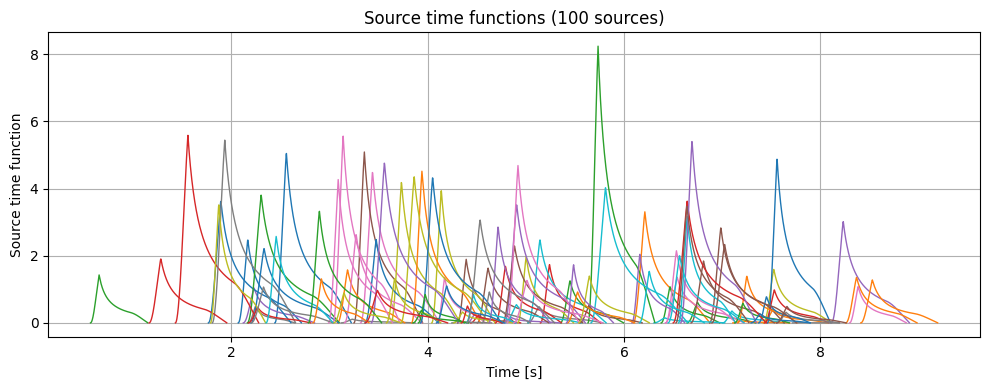

In [4]:
# the 100 slip-rate functions, each at its own rupture time tt (no legend)
plt.figure(figsize=(10, 4))
for i in range(len(x)):
    dt, npts, off = float(dt_all[i]), int(npts_all[i]), int(offsets[i])
    t = float(tt[i]) + np.arange(npts) * dt
    plt.plot(t, values[off:off + npts], linewidth=1)
plt.xlabel('Time [s]'); plt.ylabel('Source time function')
plt.title('Source time functions (100 sources)')
plt.grid(True); plt.tight_layout(); plt.show()

### The stations

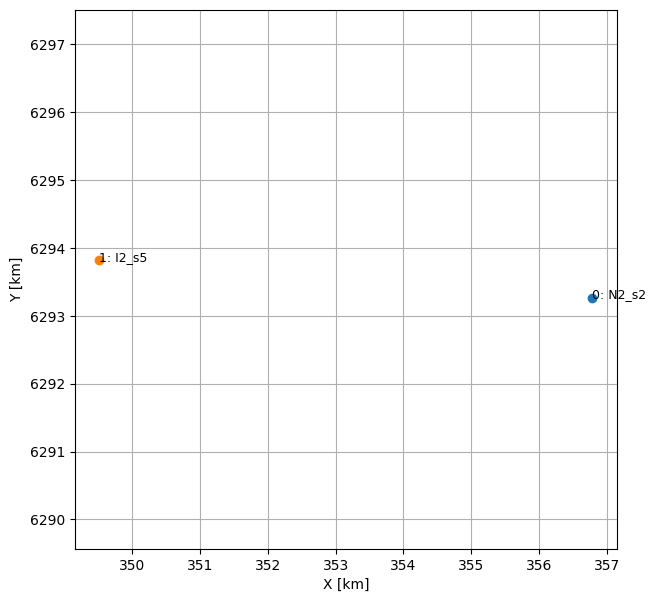

In [5]:
with h5py.File(PACKAGE_H5, 'r') as f:
    g = f['stations']
    xyz, internal, meta_raw = g['xyz_km'][:], g['internal'][:], g['metadata'][:]

stations_list = []
for i in range(len(xyz)):
    txt = meta_raw[i].decode() if isinstance(meta_raw[i], bytes) else meta_raw[i]
    try:
        meta = ast.literal_eval(txt)
    except Exception:
        meta = {'name': 'sta_%d' % i}
    stations_list.append(Station(xyz[i], internal=bool(internal[i]), metadata=meta))

stations = StationList(stations_list, metadata={'name': 'from_sw4_package'})

plt.figure(figsize=(7, 7))
for i, sta in enumerate(stations_list):
    yy, xx, zz = sta.x
    plt.scatter(xx, yy)
    plt.text(xx, yy, '%d: %s' % (i, sta.metadata.get('name', '')), fontsize=9)
plt.xlabel('X [km]'); plt.ylabel('Y [km]'); plt.axis('equal'); plt.grid(True); plt.show()

## Step 2 — Run the FK engine

Heavy run (`nfft=32768` x 100 sources). For real use launch the **script** under MPI: `mpiexec -n 8 python ../shaker_vs_sw4.py`.

In [6]:
model = shakermaker.ShakerMaker(crust, fault, stations)
model.check_parameters(dt=0.0025, nfft=8192 * 4, dk=0.2, tb=800, tmax=60)

 ShakerMaker . PARAMETER CHECK            you set:  dt + tmax
 YOU CHOSE     dt = 0.0025 s        tmax = 60 s
 GEOMETRY      r_max 29.4 km . src-rcv sep 2.9-12.9 km . Vs_min 750 m/s
               Vp_max 7000 m/s . V_Ray 0.69 km/s
               physical signal window  t = [2.7, 60.3] s  (lasts 57.6 s)
----------------------------------------------------------------------
 dt = 0.0025 s   sets your FREQUENCY BAND                       [info]
   f_Nyq         = 1/(2*dt)                   = 200 Hz       [fk.f:72]
   f_max usable  = (1-taper)*f_Nyq, taper=0.9 = 20 Hz        [fk.f:74]
   above 20 Hz   fades out smoothly, fully gone by 200 Hz    [fk.f:169]
   lambda_min    = Vs_min/f_max               = 750/20 = 37.5 m
     element size (N=10 pts/wavelength), for YOUR mesh:
        dx <= lambda_min/N    = 37.5/10 = 3.75 m
        dt <= C*dx/Vp_surf    = 1*3.75/1320 = 0.0028 s
        (Vp_surf = Vp of the soft Vs_min layer, NOT Vp_max:
         the 3.8 m elements live in the soft surface lay

{'passed': True,
 'recommended': {'dk': 0.4, 'tb': 800, 'nfft': 32768, 'tmax': 60.3}}

In [7]:
model.run(dt=0.0025, nfft=8192 * 4, dk=0.2, tb=800, tmax=60,
          tmin=0.0, sigma=2, pmax=1, nx=1, kc=15.0, verbose=True)



ShakerMaker Run begin. dt=0.0025 nfft=32768 dk=0.2 tb=800 tmin=0.0 tmax=60
--------------------------------------------------------------------------
rank=0 nprocs=1 ipair=0 skip_pairs=1 npairs=200 !!
calling core START
_call_core
        psource.x = [6.29177749e+03 3.67360696e+02 6.15198565e+00]
        station.x = [6293.26331073  356.78500779    0.        ]
ShakerMaker._call_core - calling core.subgreen
	mb: 5
	src: 4
	rcv: 1
	styoe: 2
	updn: 0
	d: [0.2        0.8        5.15198565 9.34801435 0.        ]
	a: [1.32 2.75 5.5  5.5  7.  ]
	b: [0.75 1.57 3.14 3.14 4.  ]
	rho: [2.4  2.5  2.5  2.5  2.67]
	qa: [1000. 1000. 1000. 1000. 1000.]
	qb: [1000. 1000. 1000. 1000. 1000.]
	dt: 0.0025
	nfft: 32768
	tb: 800
	nx: 1
	sigma: 2
	smth: 1
	wc1: 1
	wc2: 2
	pmin: 0
	pmax: 1
	dk: 0.2
	kc: 15.0
	taper: 0.9
	x: 10.679552149418575
	pf: 6.248278617858887
	df: 0.9052079319953918
	lf: 1.607060432434082
	sx: 6291.777493346475
	sy: 367.3606959834075
	rx: 6293.263310727202
	ry: 356.78500778720576
	
call

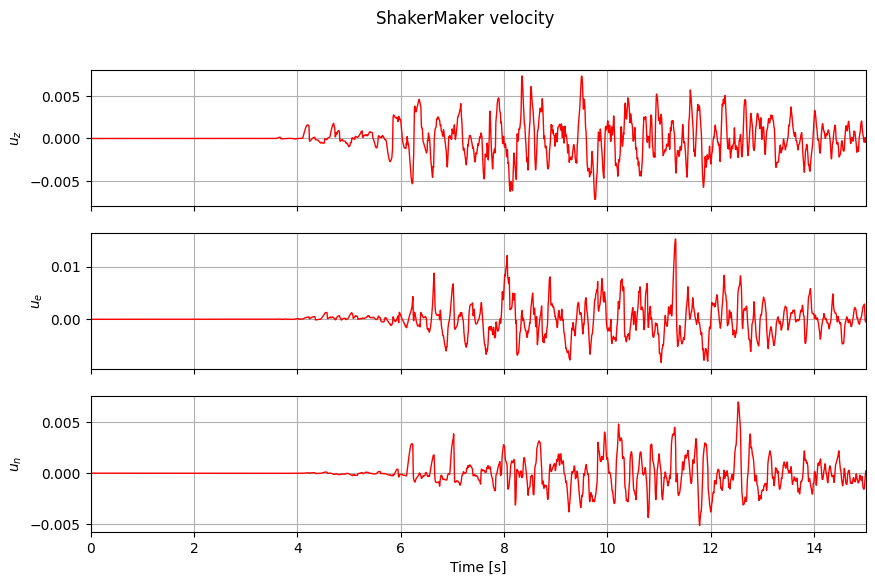

In [8]:
sta = stations.get_station_by_id(0)
z_sm, e_sm, n_sm, t_sm = sta.get_response()

fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k, (d, lab) in enumerate([(z_sm, r'$u_z$'), (e_sm, r'$u_e$'), (n_sm, r'$u_n$')]):
    ax[k].plot(t_sm, d, 'r', lw=1); ax[k].set_xlim(0, 15)
    ax[k].set_ylabel(lab); ax[k].grid(True)
ax[2].set_xlabel('Time [s]'); fig.suptitle('ShakerMaker velocity'); plt.show()

## Step 3 — Read and band-pass the SW4 output

SW4 columns `(time, x, y, z)` map to `u_z=z, u_e=y, u_n=x`. Band-pass with ObsPy to the FK band so both are compared on equal footing.

In [9]:
from obspy import Trace

def read_sw4_station(name):
    a = np.loadtxt(DATA / ('%s.txt' % name), skiprows=13)
    return a[:, 0], a[:, 3], a[:, 2], a[:, 1]   # t, u_z, u_e, u_n

def bandpass(sig, dt):
    tr = Trace(data=sig.astype(np.float32)); tr.stats.delta = dt
    tr.filter('bandpass', freqmin=FMIN, freqmax=FMAX, corners=4, zerophase=True)
    return tr.data

t_s, z_s, e_s, n_s = read_sw4_station('sf00001')
dt_s = t_s[1] - t_s[0]
z_f, e_f, n_f = bandpass(z_s, dt_s), bandpass(e_s, dt_s), bandpass(n_s, dt_s)

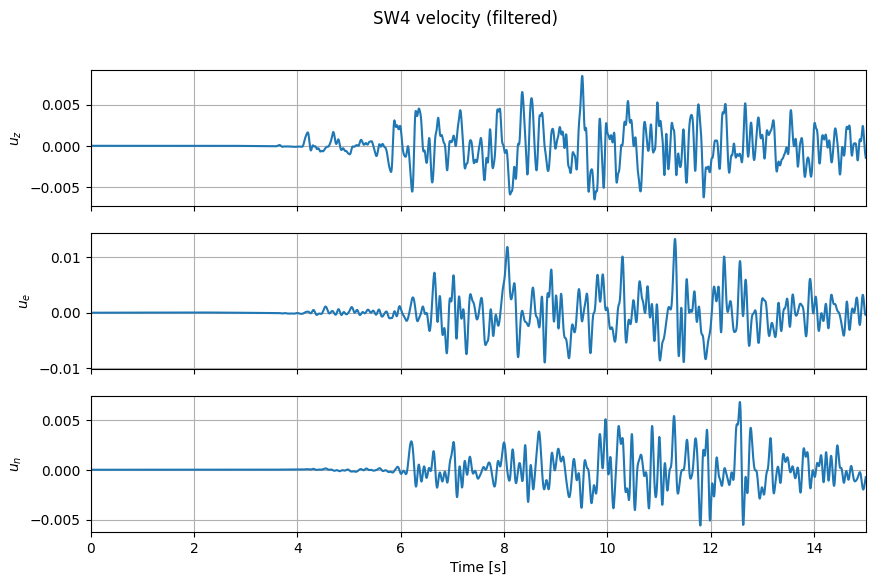

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k, (d, lab) in enumerate([(z_f, r'$u_z$'), (e_f, r'$u_e$'), (n_f, r'$u_n$')]):
    ax[k].plot(t_s, d); ax[k].set_xlim(0, 15); ax[k].set_ylabel(lab); ax[k].grid(True)
ax[2].set_xlabel('Time [s]'); fig.suptitle('SW4 velocity (filtered)'); plt.show()

## Step 4 — Overlay and compare

FK (red) vs SW4 (dashed). Matching arrival times, phases and amplitudes across all three components is the cross-validation.

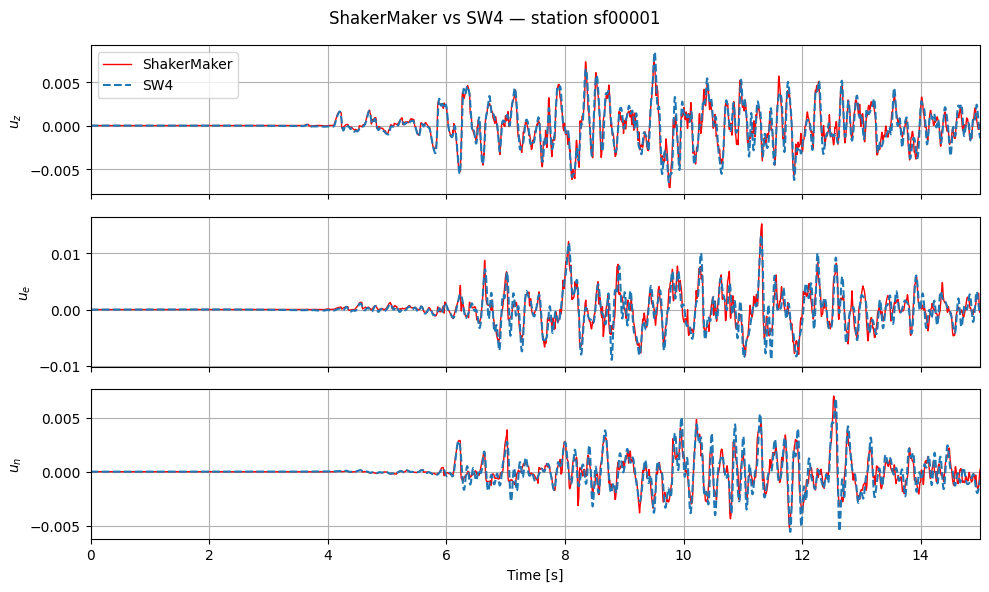

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
for k, (sm, sw, lab) in enumerate([(z_sm, z_f, r'$u_z$'),
                                   (e_sm, e_f, r'$u_e$'),
                                   (n_sm, n_f, r'$u_n$')]):
    ax[k].plot(t_sm, sm, 'r', lw=1, label='ShakerMaker')
    ax[k].plot(t_s, sw, '--', label='SW4')
    ax[k].set_xlim(0, 15); ax[k].set_ylabel(lab); ax[k].grid(True)
ax[0].legend(loc='upper left'); ax[2].set_xlabel('Time [s]')
fig.suptitle('ShakerMaker vs SW4 — station sf00001'); plt.tight_layout(); plt.show()